# Start of the Sensitivity Analysis of the RCMs 

Program to read in the zarr collection of an RCM and its corresponding FFDI files and explore FFDI drivers

This code reads in the atmospheric data, computes the DI index and then does the correlations between atm
and FFDI for the 95% of FFDI


FFDI code needs the following kernel!
3-23-.10




#### required packages

In [1]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime

from xclim.indices import (
    keetch_byram_drought_index,
    griffiths_drought_factor,
    mcarthur_forest_fire_danger_index
)

%load_ext autoreload
%autoreload 2


# importing sys
import sys
# adding plotting module to the system path
sys.path.insert(0, '/g/data/xv83/rxm599/acs/plotting_maps')
# import ACS plotting maps and Xarray.
from acs_plotting_maps import *
from acs_area_statistics import acs_regional_stats, get_regions

import geopandas as gpd
import pandas as pd
import regionmask

sys.path.insert(0, '/g/data/xv83/rxm599/acs/hazard_fire/paper2')
import sa as sa


#### start a local Dask client

In [2]:
from dask.distributed import Client, LocalCluster
import dask
import os

# --- Dask optimiser-style settings ---
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
#    "distributed.worker.memory.target": False,
#    "distributed.worker.memory.spill": False,
#    "distributed.worker.memory.pause": False,
#    "distributed.worker.memory.terminate": False,
})

# --- Match ARE allocation ---
ncpus = int(os.environ.get("PBS_NCPUS", 1))

cluster = LocalCluster(
    n_workers=ncpus,      # one worker per CPU
    threads_per_worker=1, # critical (matches optimiser)
    processes=True,
    memory_limit=0        # removes worker memory limit
)

client = Client(cluster)
client

INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/jobfs/165000271.gadi-pbs/dask-scratch-space/scheduler-f21tvp58', purging
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39961
INFO:distributed.scheduler:  dashboard at:         /proxy/8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40947'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46179'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33909'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40493'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37921'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33433'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36291'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44765 name: 1
INFO:distributed.scheduler:Starting worker comp

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39961,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36293,Total threads: 1
Dashboard: /proxy/39583/status,Memory: 0 B
Nanny: tcp://127.0.0.1:40947,


INFO:distributed.nanny:Worker process 3268010 was killed by signal 11
INFO:distributed.core:Connection to tcp://127.0.0.1:33216 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:41209 name: 4 (stimulus_id='handle-worker-cleanup-1775608827.9035943')
INFO:distributed.core:Connection to tcp://127.0.0.1:33178 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36293 name: 0 (stimulus_id='handle-worker-cleanup-1775608828.1091392')
INFO:distributed.nanny:Worker process 3267992 was killed by signal 11
INFO:distributed.core:Connection to tcp://127.0.0.1:33218 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:32953 name: 6 (stimulus_id='handle-worker-cleanup-1775608828.3664699')
INFO:distributed.nanny:Worker process 3268017 was killed by signal 11
INFO:distributed.core:Connection to tcp://127.0.0.1:33206 has been closed.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:36125 name: 5 (stimulus_i

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Set parameters

In [4]:
# parameters
# 0,2,3 failed
mindex=1
#lon1=140; lon2=150 
#lat1=-45; lat2= -32
#lat1=-45 lat2= -40 lon1=144 lon2=149
lat1=-45
lat2= -10
lon1=110
lon2=155
p_ext=0.95
p_ext=0.99

#lon1=145 ; lon2=146
#lat1=-37 ; lat2=-36
t1='2015-01-01'
t2='2035-01-01'
dirstore='sa_2020'
#dirstore='sa_obs'

In [5]:
# extra info
mindexp100=mindex+100
mobs=39

## Obtain the desired catalogues of the simulations to processe

In [6]:
dtype='/g/data/ia39/ncra/fire/bias-output/'
zarr_path=dtype+ 'zarr/*ssp370*'
ffdi_path=dtype+'ffdi/*ssp370*FFDI*'
kbdi_path=dtype+'ffdi/*ssp370*KBDI*'
# observations 
zobs='/g/data/ia39/ncra/fire/bias-input/zarr/*ERA*' 
fobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*FFDI*'
kobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*KBDI*'

mRuns = sorted(glob(zarr_path)) + sorted(glob(zobs))
mFFDI = sorted(glob(ffdi_path))+ sorted(glob(fobs))
mKBDI = sorted(glob(kbdi_path)) + sorted(glob(kobs))
print(len(mRuns))
print(len(mFFDI))

# print code to ensure the files match
ifile=-1
for file in mRuns: 
    ifile=ifile+1
    print(ifile, file)
ifile=-1
for file in mFFDI: 
    ifile=ifile+1
#    print(ifile, file)
   

40
40
0 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_ACCESS-CM2_ssp370_r4i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
1 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
2 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_CESM2_ssp370_r11i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
3 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_CMCC-ESM2_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
4 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_EC-Earth3_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
5 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_MPI-ESM1-2-HR_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
6 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_NorESM2-MM_ssp370_r1i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
7 /g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_CSIRO_ACCESS-CM2_ssp370_r4

# Process one ensemble 

In [7]:
# From one catalogue list save variables
ds0=xr.open_zarr(mRuns[mindex])
df0=xr.open_zarr(mFFDI[mindex])
dk0=xr.open_zarr(mKBDI[mindex])

print(mRuns[mindex])
print(mFFDI[mindex])
print(mKBDI[mindex])


# compute DF 
# kbdi has a 20 extra points at the start for DF calculation
if mindex != mobs: 
# for projections    
    pra = ds0.prAdjust.sel(time=slice(ds0.prAdjust.time[0],'2099-12-31'))
#    pra = pra1.transpose("lat", "lon","time")
#    pra = ds0.prAdjust.sel(time=slice(ds0.prAdjust.time[0],'2100-01-01')) # kbdi does not have data beyond end of december
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
# Reorder KBDI to match (time, lat, lon)
#    kbdi = KBDI.transpose("time", "lat", "lon")
    DF = griffiths_drought_factor(pra, kbdi)
else:
    print("obs")
    pra = ds0.pr.sel(time=slice(ds0.pr.time[0],'2100-01-01'))
#    pra = pra1.transpose("lat", "lon","time")
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
# Reorder KBDI to match (time, lat, lon)
#    kbdi = KBDI.transpose("time", "lat", "lon")
    DF = griffiths_drought_factor(pra, kbdi)
    
print(pra)
print(kbdi)
print(DF)

/g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_FFDI.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_KBDI.zarr
<xarray.DataArray 'prAdjust' (time: 31046, lat: 691, lon: 886)> Size: 76GB
dask.array<getitem, shape=(31046, 691, 886), dtype=float32, chunksize=(31046, 33, 43), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248kB 2015-01-01T12:00:00 ... 2099-12-31T1...
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          mm d

In [8]:
# compute the 95% value from first 20 years
if mindex != mobs:
    tr1='2015-01-01'; tr2='2035-01-01'
# should be changed to     tr1='2015-01-01'; tr2='2035-01-01'
else:
    tr1='2000-01-01'; tr2='2020-01-01'
    t1=tr1; t2=tr2
# should be changed to tr1='2004-01-01'; tr2='2024-01-01' 
#    tr1='2003-01-01'; tr2='2023-12-31'

df1=df0.sel(time=slice(tr1,tr2))
d95a=df1.FFDI.quantile(p_ext,dim='time')

print(df1)

<xarray.Dataset> Size: 18GB
Dimensions:  (lat: 691, lon: 886, time: 7306)
Coordinates:
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * time     (time) datetime64[ns] 58kB 2015-01-01T12:00:00 ... 2035-01-01T12...
Data variables:
    FFDI     (lat, lon, time) float32 18GB dask.array<chunksize=(33, 43, 7306), meta=np.ndarray>


## mask info

In [9]:
%%time
# NCRA regions from acs_area_statistics code
# these are the names of your regions
regions = get_regions([
                           "australia"
                      ])
regions
# nrm_regions ncra_regions",


CPU times: user 22.4 s, sys: 581 ms, total: 23 s
Wall time: 20.2 s


<regionmask.Regions 'australia'>
overlap:  True

Regions:
0 AUS Australia

[1 regions]

In [10]:
mask_frac = regions.mask_3D(d95a)
#mask_frac = regions.mask_3D_frac_approx(d95) # not defined in 3-23.10

In [11]:
mask_ = mask_frac.isel(region=0)
mask_
d95=d95a.where(mask_).load()

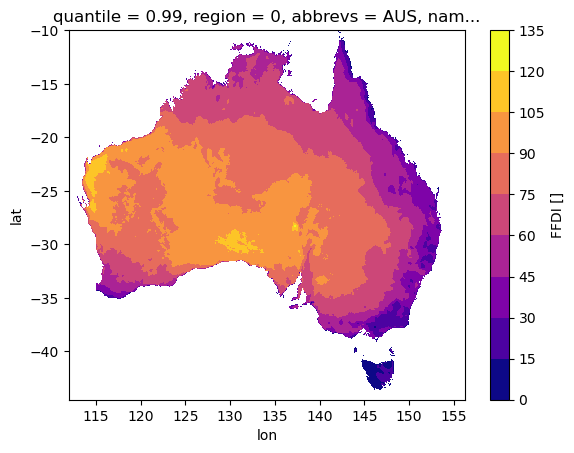

In [12]:
d95.plot(cmap='plasma',levels=10)

In [13]:
df2=df0.sel(time=slice(t1,t2))
dfe95=df0.FFDI.where(df2.FFDI > d95)


In [14]:
df2=df0.sel(time=slice(t1,t2))
ds2=ds0.sel(time=slice(t1, t2))
dk2=dk0.sel(time=slice(t1,t2))
dd2=DF.sel(time=slice(t1,t2))
# extract only the values greater than FFDI > 95%
dfe95=df0.FFDI.where(df2.FFDI > d95)
dse95=ds0.where(df2.FFDI > d95)
dke95=dk0.where(df2.FFDI > d95)
dde95=DF.where(df2.FFDI > d95)
print(dfe95)
print(dse95)
print(dke95)
print(dde95)

<xarray.DataArray 'FFDI' (lat: 691, lon: 886, time: 7306)> Size: 18GB
dask.array<where, shape=(691, 886, 7306), dtype=float32, chunksize=(33, 43, 7306), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * time      (time) datetime64[ns] 58kB 2015-01-01T12:00:00 ... 2035-01-01T1...
    quantile  float64 8B 0.99
    region    int64 8B 0
    abbrevs   <U3 12B 'AUS'
    names     <U9 36B 'Australia'
Attributes:
    units:    
<xarray.Dataset> Size: 125GB
Dimensions:           (time: 7306, lat: 691, lon: 886, bnds: 2)
Coordinates:
  * time              (time) datetime64[ns] 58kB 2015-01-01T12:00:00 ... 2035...
  * lat               (lat) float64 6kB -44.5 -44.45 -44.4 ... -10.05 -10.0
  * lon               (lon) float64 7kB 112.0 112.0 112.1 ... 156.2 156.2 156.2
  * bnds              (bnds) float64 16B 0.0 1.0
    lon_bnds          (lon, bnds)

In [15]:
dd2

<xarray.DataArray 'prAdjust' (lat: 691, lon: 886, time: 7306)> Size: 18GB
dask.array<getitem, shape=(691, 886, 7306), dtype=float32, chunksize=(33, 43, 7306), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 6kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
  * time     (time) datetime64[ns] 58kB 2015-01-01T12:00:00 ... 2035-01-01T12...
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          1

In [16]:
# fixed naming in UQ-DEC files
print(list(dse95.data_vars))
var=list(dse95.data_vars)
for jj in list(dse95.data_vars):
    if (jj == 'sfcWindAdjust'):
        qt=True
        ddnew=dse95.rename({'sfcWindAdjust': 'sfcWindmaxAdjust'})
        dse95=ddnew

print(list(dse95.data_vars))

['prAdjust', 'tasminAdjust', 'sfcWindmaxAdjust', 'rsdsAdjust', 'hursmaxAdjust', 'tasmaxAdjust', 'hursminAdjust']
['prAdjust', 'tasminAdjust', 'sfcWindmaxAdjust', 'rsdsAdjust', 'hursmaxAdjust', 'tasmaxAdjust', 'hursminAdjust']


In [17]:
%%time
FT=dfe95
# compute seasonal diagnostics for subsequent use
mask=FT.notnull()
days = xr.where(mask, 1, np.nan)
tot_days=(days.groupby('time.season').sum('time')+d95*0).load()
seasonal_clim = (FT.groupby('time.season').mean('time')).load()


CPU times: user 15.5 s, sys: 2.03 s, total: 17.5 s
Wall time: 1min 9s


In [18]:
%%time
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_ffdi_ex.nc'
outf1='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_ffdi_t.zarr'

d95.name='FFDI_mean'
dfe95.name='FFDI_t'
tot_days.name='tot_days'
seasonal_clim.name='seasonal_clim'

# compute the p-ext% value for the 20 years of the analysis
ffdi0=df0.sel(time=slice(t1,t2))
ffdi1=ffdi0.FFDI.quantile(p_ext,dim='time')
ffdi2=ffdi1.where(mask_).load()
ffdi2.name='FFDI_mean'

# compare reference date (tr1) with start date of analysis (t1)
if t1 == tr1 :
    print("Times are equal")
    dfout=xr.merge([d95,tot_days,seasonal_clim])
else:
    print("Times are NOT equal")
    dfout=xr.merge([ffdi2,tot_days,seasonal_clim])

# Only create file if it does not exist
print(outf)
if os.path.exists(outf):
    print("File exists!",outf)
    ddtmp1=xr.open_dataset(outf)
else:
    print("File does not exist. ",outf)
    dfout.to_netcdf(outf, mode='w')
    ddtmp1=xr.open_dataset(outf)
    
if os.path.exists(outf1):
    print("File exists!",outf1)
    ddtmp2=xr.open_zarr(outf1)
else:
    print("File does not exist. ",outf1)
    dfe95.to_zarr(outf1, mode='w',zarr_format=2)
    ddtmp2=xr.open_zarr(outf1)




Times are equal
/scratch/xv83/rxm599/sa_2020/model_101_ffdi_ex.nc
File does not exist.  /scratch/xv83/rxm599/sa_2020/model_101_ffdi_ex.nc
File does not exist.  /scratch/xv83/rxm599/sa_2020/model_101_ffdi_t.zarr
CPU times: user 14.5 s, sys: 2.22 s, total: 16.7 s
Wall time: 1min 4s


In [19]:
# example code fix for problems with zarr v3 but using zarr_format=2 seems to fix it
#dfe95
#encoding = {var: {"compressor": None} for var in dfe95.coords}
#dfe95.to_zarr(outf1, mode='w',encoding=encoding)

In [23]:
%%time
# Reduce workers for IO phase
cluster.scale(4)   # e.g. 2–6 workers is usually good

# Only create file if it does not exist
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_dde95.zarr'
outft='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_dde95.nc'
print(outf)
#dde95.load()
if os.path.exists(outf):
    print("File exists!")
    ddtmp=xr.open_zarr(outf)
else:
    print("File does not exist.")
#    dde95.to_zarr(outf, mode='w',encoding=encoding)
    dde95.to_zarr(outf, mode='w',zarr_format=2)
#    dfe95.to_netcdf(outft, mode='w')
    ddtmp=xr.open_zarr(outf)

cluster.scale(n_workers_full)


INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:37921'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:33433'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:36291'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:37921' closed.
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:33433' closed.


/scratch/xv83/rxm599/sa_2020/model_101_dde95.zarr
File does not exist.


INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:36291' closed.
2026-04-08 10:46:48,765 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:41059
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/worker.py", line 2081, in gather_dep
    response = await get_data_from_worker(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/worker.py", line 2887,

CPU times: user 6.11 s, sys: 867 ms, total: 6.97 s
Wall time: 31.8 s


KilledWorker: Attempted to run task ('griffiths_drought_factor_pass-griffiths_drought_factor_pass_0-083ba31dc790e675f7e595fcadc7a3b9', 9, 9, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:35493. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [30]:
dde95
#dde95.isel(time=0).compute()
#dde95.isel(time=0, lat=slice(0, 100), lon=slice(0, 100)).compute()
dde95.isel(time=0, lat=slice(0,100), lon=slice(0,100)).compute(scheduler="single-threaded")

<xarray.DataArray 'prAdjust' (lat: 100, lon: 100)> Size: 80kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100))
Coordinates:
  * lat       (lat) float64 800B -44.5 -44.45 -44.4 ... -39.65 -39.6 -39.55
  * lon       (lon) float64 800B 112.0 112.0 112.1 112.2 ... 116.8 116.9 117.0
    time      datetime64[ns] 8B 2015-01-01T12:00:00
    quantile  float64 8B 0.99
    region    int64 8B 0
    abbrevs   <U3 12B 'AUS'
    names     <U9 36B 'Australia'
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          1

In [31]:
dde95.chunks


((33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  33,
  31),
 (43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  43,
  26),
 (7306,))

In [ ]:
#print(dde95)
var_name = list(ddtmp.data_vars)[0]
dde95 = ddtmp[var_name]
dde95.mean('time').plot()

# Correlation analysis with whole dataset

In [ ]:
%%time 
# compute the average of the environmnental variables for the days when FFDI > 95% (or p_ext%)
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_ffdi_atm.nc'
print(outf)

dse95

dde95

In [ ]:
%%time 
# compute the average of the environmnental variables for the days when FFDI > 95% (or p_ext%)
outf='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_ffdi_atm.nc'
print(outf)

if mindex != mobs:
    t_ave=dse95.tasmaxAdjust.mean(dim='time')
    h_ave=dse95.hursminAdjust.mean(dim='time')
    w_ave=dse95.sfcWindmaxAdjust.mean(dim='time')
    DF_ave=dde95.mean(dim='time')
else:
    t_ave=dse95.tasmax.mean(dim='time')
    h_ave=dse95.hursmin.mean(dim='time')
    w_ave=dse95.sfcWindmax.mean(dim='time')
    DF_ave=dde95.mean(dim='time')
#t_ave.name='tasmax'
#h_ave.name='hursmin'
#w_ave.name='sfcWindmax'
#DF_ave.name='DF'
dout=xr.merge([t_ave,h_ave,w_ave,DF_ave])

if os.path.exists(outf):
    print("File exists!")
else:    
    dout.to_netcdf(outf, mode='w')



In [ ]:
%%time
# two versions 
if mindex != mobs: 
# for projections    
    r1=xr.corr(dse95.tasmaxAdjust,dfe95,dim='time').load()
    r2=xr.corr(dse95.hursminAdjust,dfe95,dim='time').load()
    r3=xr.corr(dde95,dfe95,dim='time').load()
    r4=xr.corr(dse95.sfcWindmaxAdjust,dfe95,dim='time').load()
else:
    r1=xr.corr(dse95.tasmax,dfe95,dim='time').load()
    r2=xr.corr(dse95.hursmin,dfe95,dim='time').load()
    r3=xr.corr(dde95,dfe95,dim='time').load()
    r4=xr.corr(dse95.sfcWindmax,dfe95,dim='time').load()
 

In [ ]:
%%time
#Correlation with FFDI
outf1='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_corr.nc'
print(mindex)
print(outf1)
if os.path.exists(outf1):
    print("File exists!")
else:
    print("File does not exist.")
    r1.name='r1'
    r2.name='r2'
    r3.name='r3'
    r4.name='r4'
    ds = xr.merge([r1,r2,r3,r4])
    ds.to_netcdf(outf1)



In [ ]:
%%time
lev1=np.arange(-.80, 1, .20)
plt.figure(figsize=(12, 12))
plt.subplot(2,2,1); r1.plot(levels=lev1,extend='both')
plt.title("Tmax - FFDI")
plt.subplot(2,2,2); r2.plot(levels=lev1,extend='both')
plt.title("Hmin - FFDI")
plt.subplot(2,2,3); r3.plot(levels=lev1,extend='both')
plt.title("DF - FFDI")
plt.subplot(2,2,4); r4.plot(levels=lev1,extend='both')
plt.title("Wmax - FFDI")


In [ ]:
%%time
# correlations between FFDI variables
if mindex != mobs: 
# for projections    
    r1=xr.corr(dde95,dse95.hursminAdjust,dim='time').load()
    r2=xr.corr(dde95,dse95.tasmaxAdjust,dim='time').load()
    r3=xr.corr(dde95,dse95.sfcWindmaxAdjust,dim='time').load()
    r4=xr.corr(dse95.tasmaxAdjust,dse95.hursminAdjust,dim='time').load()
    r5=xr.corr(dse95.tasmaxAdjust,dse95.sfcWindmaxAdjust,dim='time').load()
    r6=xr.corr(dse95.sfcWindmaxAdjust,dse95.hursminAdjust,dim='time').load()
else:
    r1=xr.corr(dde95,dse95.hursmin,dim='time').load()
    r2=xr.corr(dde95,dse95.tasmax,dim='time').load()
    r3=xr.corr(dde95,dse95.sfcWindmax,dim='time').load()
    r4=xr.corr(dse95.tasmax,dse95.hursmin,dim='time').load()
    r5=xr.corr(dse95.tasmax,dse95.sfcWindmax,dim='time').load()
    r6=xr.corr(dse95.sfcWindmax,dse95.hursmin,dim='time').load()
 

In [ ]:
%%time
# check correlation between input variables to FFDI
plt.figure(figsize=(8,14))
lev1=np.arange(-.80, 1, .20)
#lev1=np.arange(-.90, 1, .10)
plt.subplot(3,2,1); r1.plot(levels=lev1,extend='both')
plt.title("DI - Tmax")
plt.subplot(3,2,2); r2.plot(levels=lev1,extend='both')
plt.title("DI - Hmin")
plt.subplot(3,2,3); r3.plot(levels=lev1,extend='both')
plt.title("DI - Wmax")
plt.subplot(3,2,4); r4.plot(levels=lev1,extend='both')
plt.title("Tmax - Hmin")
plt.subplot(3,2,5); r5.plot(levels=lev1,extend='both')
plt.title("Tmax - Wmax")
plt.subplot(3,2,6); r6.plot(levels=lev1,extend='both')
plt.title("Hmin - Wmax`")

In [ ]:
%%time
outf1='/scratch/xv83/rxm599/'+f'{dirstore}/'+f'model_{mindexp100}_xcorr.nc'
print(mindex)
print(outf1)

if os.path.exists(outf1):
    print("File exists!")
else:
    print("File does not exist.")
    r1.name='r1'
    r2.name='r2'
    r3.name='r3'
    r4.name='r4'
    r5.name='r5'
    r6.name='r6'
    ds = xr.merge([r1,r2,r3,r4,r5,r6])
    ds.to_netcdf(outf1)



In [ ]:
#client.shutdown()